# Introducción al Lenguaje Python 

## Universidad Austral - Pampa Energía


**abril mayo 2024**


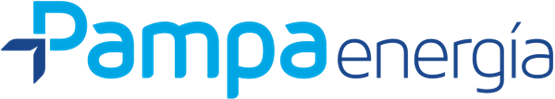

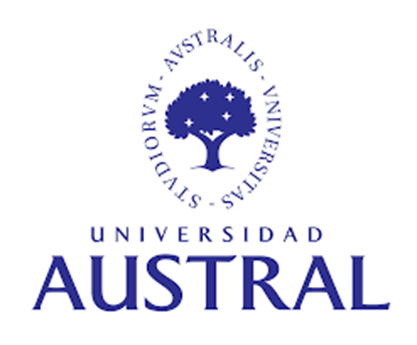

## Phd Débora Chan

# <font color="#998822">  Series Temporales</font>

Los datos obtenidos a partir de observaciones recogidas a lo largo del tiempo son muy comunes. 


En los **negocios**, observamos las tasas de interés de la semana, los precios de cierre de las acciones diarios, los índices de precios mensuales, las cifras de ventas anuales, etc. 

En **meteorología**, observamos las temperaturas máximas y mínimas diarias, los índices anuales de precipitación y de sequía, y las velocidades del viento por hora. 

En la **agricultura**, registramos las cifras anuales de producción agrícola y ganadera, la erosión del suelo, y las ventas de exportación.

En **energía** observamos la generación de energía eólica, el consumo de energía eléctrica, la demanda de energía de las empresas, etc.

## <font color="darkgreen">¿Qué es una serie temporal?</font>

Una serie de tiempo o serie temporal es una secuencia de datos, observaciones o valores, medidos en determinados momentos y ordenados cronológicamente. Los datos pueden estar espaciados a intervalos iguales o desiguales.

Una vez capturada la serie temporal, se realiza un análisis de la misma para identificar patrones en los datos, en esencia, lo que se busca es entender qué sucede a medida que el tiempo transcurre.

## Características específicas

 - Son **dependientes del tiempo**.
 
 - Suelen tener una **tendencia** y una  **estacionalidad**.
 
 - Suelen estar **autocorrelacionadas**.






## <font color="darkcyan">Suavizado de la Serie Temporal mediante medias móviles</font>


**SMA** Simple Moving Average

Uno de los métodos más simples y más utilizados para suavizar los datos de series temporales es la media móvil. Implica tomar el promedio de un número fijo de observaciones consecutivas y usarlo como el valor suavizado para el punto central. 

El número de observaciones se denomina **tamaño de ventana** y determina cuánto suavizado se aplica. 


- Un tamaño de ventana más grande significa más suavizado, pero también más retraso y pérdida de detalles.
- Un tamaño de ventana más pequeño significa menos suavizado, pero también más ruido y variabilidad.


  Puede usar la biblioteca ***pandas*** en Python para calcular la media móvil de una serie temporal utilizando los métodos ***rolling()*** y ***mean()***.

**En este primer ejemplo hagámoslo con unos datos simples**.

In [51]:
import pandas as pd
import numpy as np
product = {'month' : [1,2,3,4,5,6,7,8,9,10,11,12],'demand':[290,260,288,300,310,303,329,340,316,330,308,310]}
df = pd.DataFrame(product)

In [52]:
df['pandas_SMA_3'] = df.iloc[:,1].rolling(window=3, center=True).mean()
df

,month,demand,pandas_SMA_3
0,1,290,NaN
1,2,260,279.333333
2,3,288,282.666667
3,4,300,299.333333
4,5,310,304.333333
5,6,303,314.000000
6,7,329,324.000000
7,8,340,328.333333
8,9,316,328.666667
9,10,330,318.000000


In [54]:
df['pandas_SMA_4'] = df.iloc[:,1].rolling(window=4, center=True).mean()
df

,month,demand,pandas_SMA_3,pandas_SMA_4
0,1,290,NaN,NaN
1,2,260,279.333333,NaN
2,3,288,282.666667,284.50
3,4,300,299.333333,289.50
4,5,310,304.333333,300.25
5,6,303,314.000000,310.50
6,7,329,324.000000,320.50
7,8,340,328.333333,322.00
8,9,316,328.666667,328.75
9,10,330,318.000000,323.50


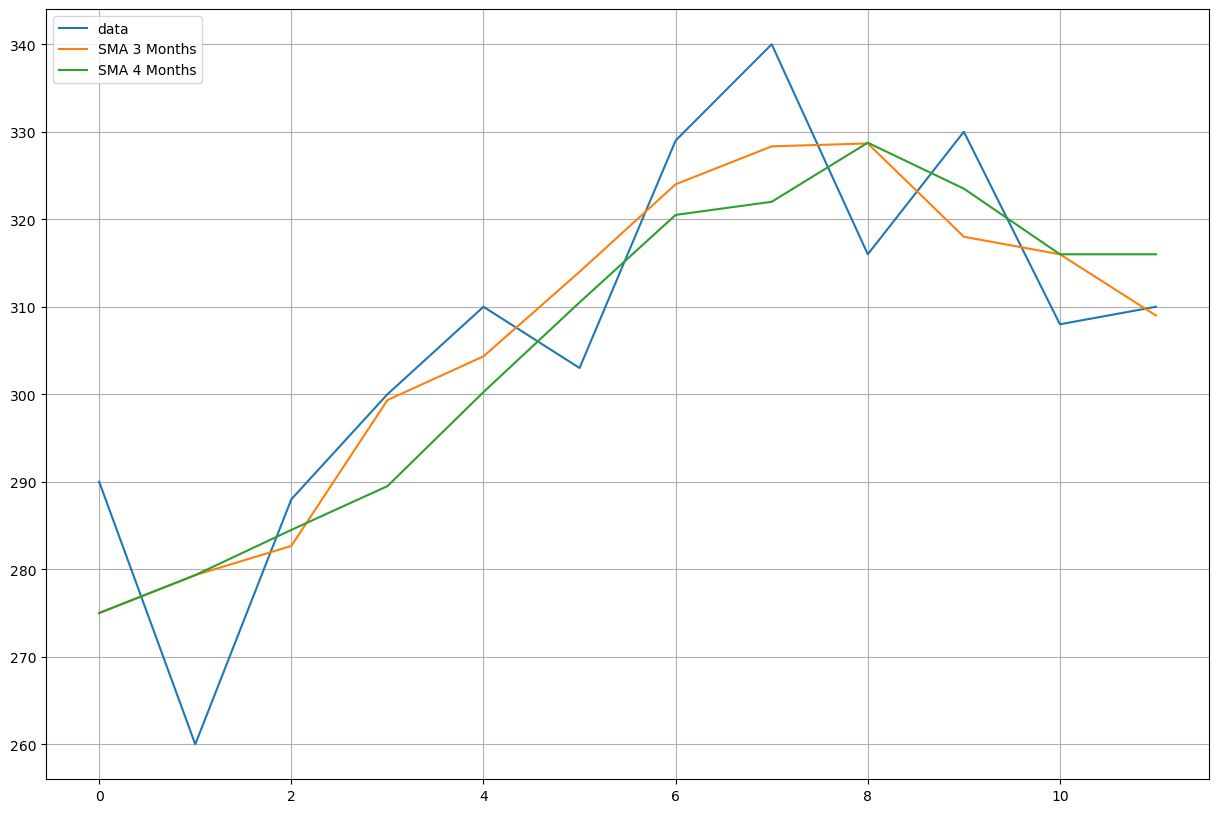

In [46]:
plt.figure(figsize=[15,10])
plt.grid(True)
plt.plot(df['demand'],label='data')
plt.plot(df['pandas_SMA_3'],label='SMA 3 Months')
plt.plot(df['pandas_SMA_4'],label='SMA 4 Months')
plt.legend(loc=2)

En este segundo ejemplo, hagámoslo con una serie temporal real.

El conjunto de datos contiene información diaria relativa al aire de la ciudad de New York durante 5 meses del año 1973, de mayo a septiembre.



In [24]:

# Cargar los datos del archivo xlsx
aire = pd.read_excel("C:/Users/Debora/Dropbox/AustralPosgrado/CursoPythonPampa/Clase7/airquality.xlsx")

# Mostrar las primeras filas del DataFrame
print(aire)

     Ozone  Solar.R  Wind  Temp  Month  Day
0     41.0    190.0   7.4    67      5    1
1     36.0    118.0   8.0    72      5    2
2     12.0    149.0  12.6    74      5    3
3     18.0    313.0  11.5    62      5    4
4      NaN      NaN  14.3    56      5    5
..     ...      ...   ...   ...    ...  ...
148   30.0    193.0   6.9    70      9   26
149    NaN    145.0  13.2    77      9   27
150   14.0    191.0  14.3    75      9   28
151   18.0    131.0   8.0    76      9   29
152   20.0    223.0  11.5    68      9   30

[153 rows x 6 columns]


In [39]:
import pandas as pd
from scipy import signal

# Crear un rango de fechas del año 1973 para armar una serie temporal con las temperaturas
date_range = pd.date_range(start='1973-05-01', end='1973-09-30')

# Crear un DataFrame con las fechas del rango y los datos de temperatura
data = {
    'Date': date_range,
    'Temp': aire['Temp'],  }

aire_temp = pd.DataFrame(data)

# Mostrar las primeras filas del DataFrame temporal
print(aire_temp.head())

        Date  Temp
0 1973-05-01    67
1 1973-05-02    72
2 1973-05-03    74
3 1973-05-04    62
4 1973-05-05    56


In [56]:
aire_temp['pandas_SMA_3'] = aire_temp.iloc[:,1].rolling(window=3,center=True).mean()
aire_temp['pandas_SMA_4'] = aire_temp.iloc[:,1].rolling(window=4,center=True).mean()
aire_temp['pandas_SMA_5'] = aire_temp.iloc[:,1].rolling(window=5,center=True).mean()
aire_temp

,Date,Temp,pandas_SMA_3,pandas_SMA_4,pandas_SMA_5
0,1973-05-01,67,NaN,NaN,NaN
1,1973-05-02,72,71.000000,NaN,NaN
2,1973-05-03,74,69.333333,68.75,66.2
3,1973-05-04,62,64.000000,66.00,66.0
4,1973-05-05,56,61.333333,64.50,64.6
...,...,...,...,...,...
148,1973-09-26,70,70.000000,69.75,70.8
149,1973-09-27,77,74.000000,71.25,72.2
150,1973-09-28,75,76.000000,74.50,73.2
151,1973-09-29,76,73.000000,74.00,NaN


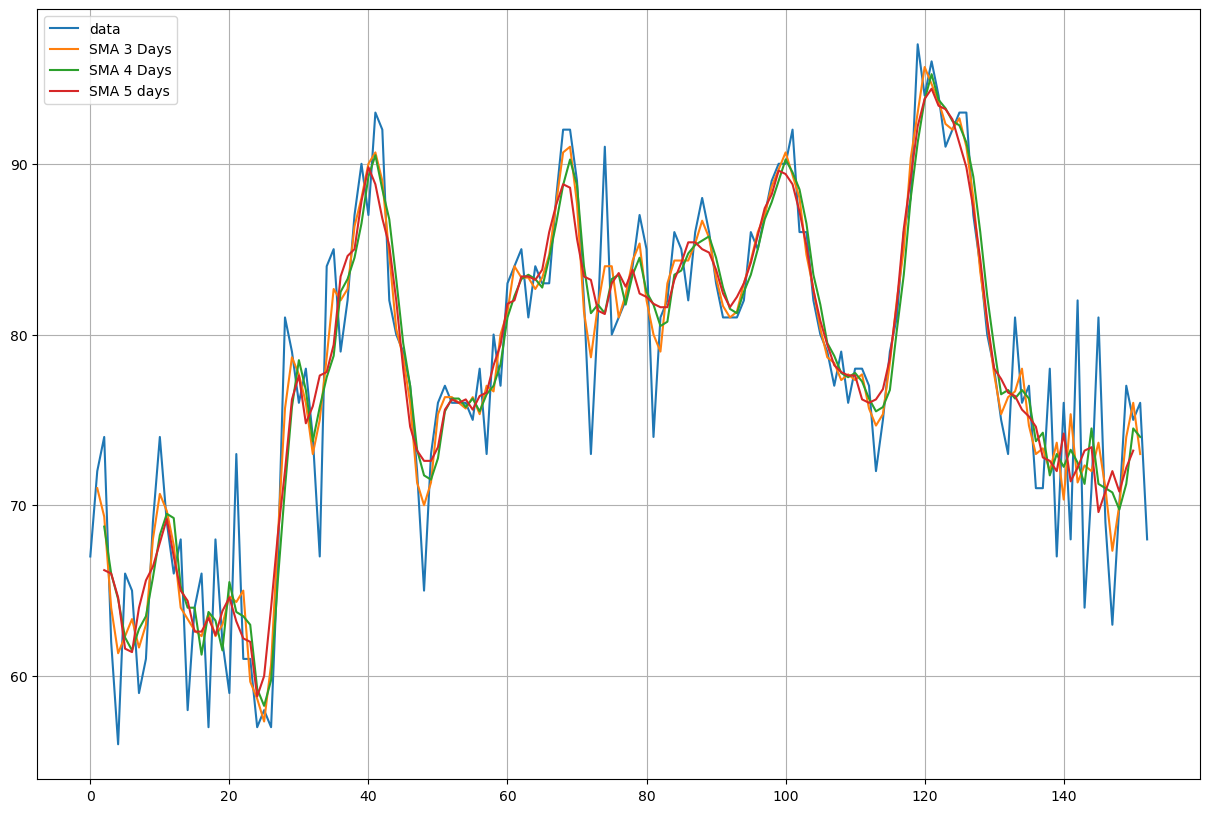

In [57]:
plt.figure(figsize=[15,10])
plt.grid(True)
plt.plot(aire_temp['Temp'],label='data')
plt.plot(aire_temp['pandas_SMA_3'],label='SMA 3 Days')
plt.plot(aire_temp['pandas_SMA_4'],label='SMA 4 Days')
plt.plot(aire_temp['pandas_SMA_5'],label='SMA 5 days')
plt.legend(loc=2)

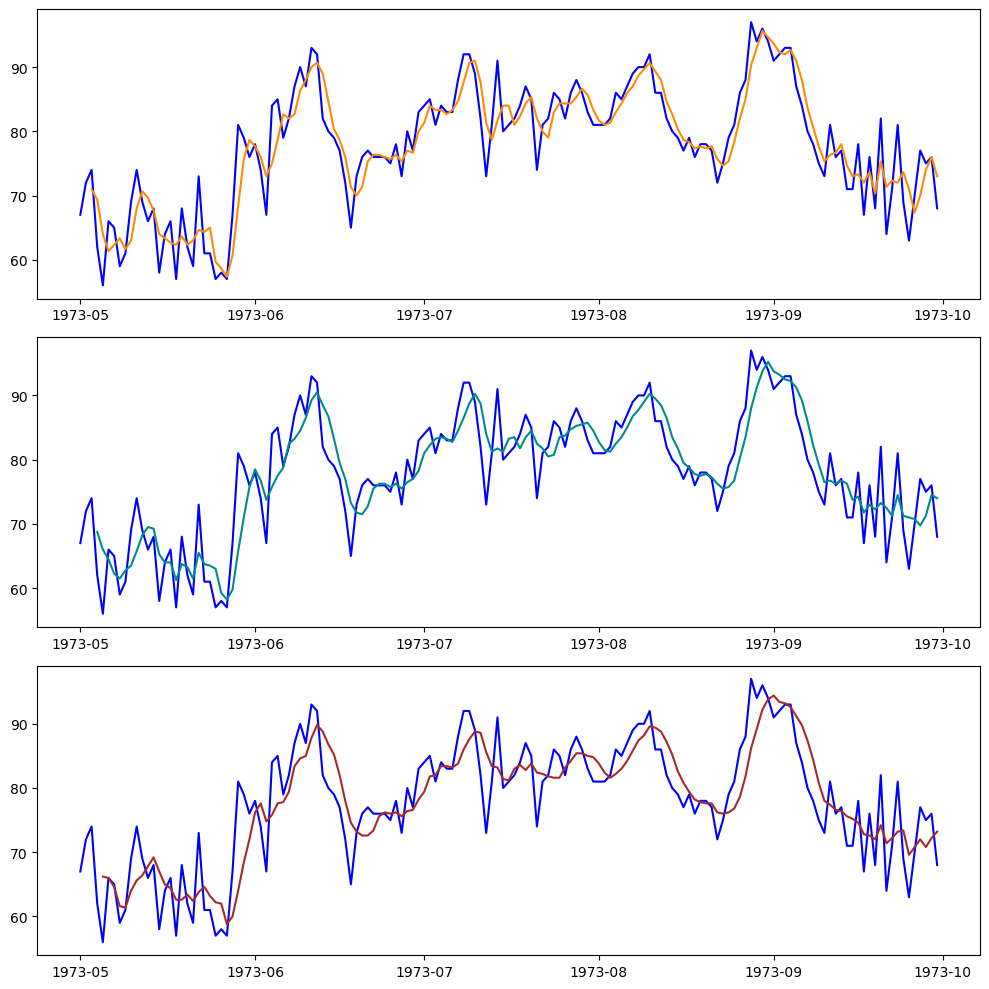

In [38]:
# Crear figuras y ejes para los tres paneles
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Paneles 1, 2 y 3: Datos originales con suavizado por medias móviles

axes[0].plot(aire_temp['Date'], aire_temp['Temp'], color='blue', label='Original')
axes[0].plot(aire_temp['Date'], aire_temp['pandas_SMA_3'], color='darkorange', label='SMA_3')   
axes[1].plot(aire_temp['Date'], aire_temp['Temp'], color='blue', label='Original')
axes[1].plot(aire_temp['Date'], aire_temp['pandas_SMA_4'], color='darkcyan', label='SMA_4')   
axes[2].plot(aire_temp['Date'], aire_temp['Temp'], color='blue', label='Original')
axes[2].plot(aire_temp['Date'], aire_temp['pandas_SMA_5'], color='brown', label='sMA_5')
# Ajustar diseño
plt.tight_layout()
plt.show()

# Ejercicio 35

a) Armar una serie temporal con las mediciones de los vientos (Wind).

b) Graficar la serie temporal de los vientos.

c) Estimar los promedio móviles con k=3, k=5 y k=7

d) Realizar un gráfico con 3 subgráficos en cada uno de los cuales aparezca la serie original y la de promedios móviles.

e) Comentar el gráfico.

# <font color="darkcyan"> Suavizado de Savitzky-Golay</font>

El suavizado por Savitzky-Golay se basa en ajustar **polinomios locales a pequeñas ventanas de datos** y luego evaluar estos polinomios en el punto central de la ventana para obtener la señal suavizada. La principal ventaja de este método es que, a diferencia de otros métodos de suavizado, no necesita alinear las muestras en el tiempo, lo que lo hace adecuado para señales irregulares o con datos faltantes.

En resumen, el suavizado por Savitzky-Golay utiliza un enfoque de ajuste polinomial local para suavizar la señal mientras conserva los detalles importantes. Es una herramienta útil en el procesamiento de señales para eliminar el ruido y mejorar la calidad de la señal sin introducir un sesgo excesivo.

<font color="#BB55FF">**Tambien en este caso se pueden utilizar distinta longitud de ventanas pero se pueden utilizar en este caso polinomios de diferente orden.**</font>



In [61]:
# Aplicar el suavizado de Savitzky-Golay a la serie temporal de temperatura con distinto ancho de ventana pero pol de grado 2
savgol_temp_9_2 = signal.savgol_filter(aire_temp['Temp'], window_length=9, polyorder=2)
savgol_temp_11_2 = signal.savgol_filter(aire_temp['Temp'], window_length=11, polyorder=2)
savgol_temp_15_2 = signal.savgol_filter(aire_temp['Temp'], window_length=15, polyorder=2)

# Agregar la serie suavizada al DataFrame
aire_temp['savgol_temp_9_2'] = savgol_temp_9_2
aire_temp['savgol_temp_11_2'] = savgol_temp_11_2
aire_temp['savgol_temp_15_2'] = savgol_temp_15_2
# Mostrar las primeras filas del DataFrame temporal con la serie suavizada
print(aire_temp.head())

        Date  Temp  pandas_SMA_3  pandas_SMA_4  pandas_SMA_5  \
0 1973-05-01    67           NaN           NaN           NaN   
1 1973-05-02    72     71.000000           NaN           NaN   
2 1973-05-03    74     69.333333         68.75          66.2   
3 1973-05-04    62     64.000000         66.00          66.0   
4 1973-05-05    56     61.333333         64.50          64.6   

   savgol_temp_15_2  savgol_temp_9_2  savgol_temp_11_2  
0         68.217647        70.739394         72.636364  
1         67.460084        68.751515         68.836364  
2         66.795443        66.964935         65.854545  
3         66.223723        65.379654         63.690909  
4         65.744926        63.995671         62.345455  


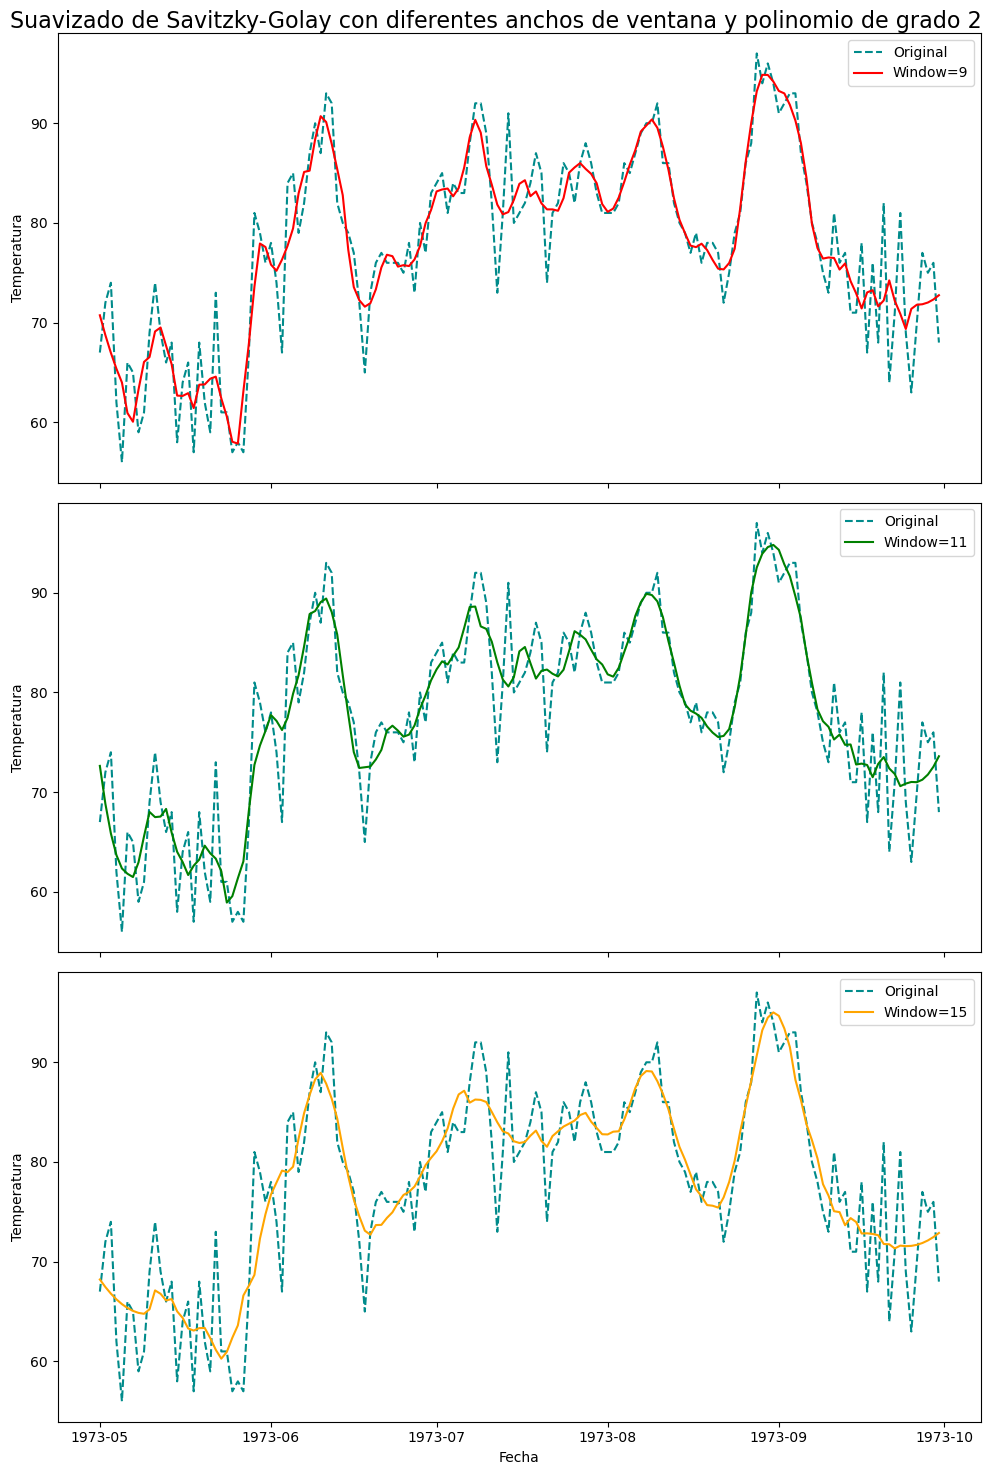

In [71]:
import matplotlib.pyplot as plt

# Crear una figura con tres subfiguras
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

# Graficar cada subfigura con la serie original y suavizada correspondiente
axes[0].plot(aire_temp['Date'], aire_temp['Temp'], label='Original', color='darkcyan', linestyle='--')
axes[0].plot(aire_temp['Date'], aire_temp['savgol_temp_9_2'], label='Window=9', color='red')
axes[0].set_ylabel('Temperatura')
axes[0].legend()

axes[1].plot(aire_temp['Date'], aire_temp['Temp'], label='Original', color='darkcyan', linestyle='--')
axes[1].plot(aire_temp['Date'], aire_temp['savgol_temp_11_2'], label='Window=11', color='green')
axes[1].set_ylabel('Temperatura')
axes[1].legend()

axes[2].plot(aire_temp['Date'], aire_temp['Temp'], label='Original', color='darkcyan', linestyle='--')
axes[2].plot(aire_temp['Date'], aire_temp['savgol_temp_15_2'], label='Window=15', color='orange')
axes[2].set_ylabel('Temperatura')
axes[2].legend()

# Configurar el título y etiquetas de los ejes
plt.xlabel('Fecha')
plt.suptitle('Suavizado de Savitzky-Golay con diferentes anchos de ventana y polinomio de grado 2', fontsize=16)

# Ajustar el diseño
plt.tight_layout()
plt.show()

In [64]:
# Aplicar el suavizado de Savitzky-Golay a la serie temporal de temperatura con  grado del polinomio
savgol_temp_11_2 = signal.savgol_filter(aire_temp['Temp'], window_length=11, polyorder=2)
savgol_temp_11_3 = signal.savgol_filter(aire_temp['Temp'], window_length=11, polyorder=3)
savgol_temp_11_5 = signal.savgol_filter(aire_temp['Temp'], window_length=11, polyorder=5)

# Agregar la serie suavizada al DataFrame

aire_temp['savgol_temp_11_2'] = savgol_temp_11_2
aire_temp['savgol_temp_11_3'] = savgol_temp_11_3
aire_temp['savgol_temp_11_5'] = savgol_temp_11_5
# Mostrar las primeras filas del DataFrame temporal con la serie suavizada
print(aire_temp.head())

        Date  Temp  pandas_SMA_3  pandas_SMA_4  pandas_SMA_5  \
0 1973-05-01    67           NaN           NaN           NaN   
1 1973-05-02    72     71.000000           NaN           NaN   
2 1973-05-03    74     69.333333         68.75          66.2   
3 1973-05-04    62     64.000000         66.00          66.0   
4 1973-05-05    56     61.333333         64.50          64.6   

   savgol_temp_15_2  savgol_temp_9_2  savgol_temp_11_2  savgol_temp_11_3  \
0         68.217647        70.739394         72.636364         69.440559   
1         67.460084        68.751515         68.836364         69.475524   
2         66.795443        66.964935         65.854545         68.198135   
3         66.223723        65.379654         63.690909         66.141026   
4         65.744926        63.995671         62.345455         63.836830   

   savgol_temp_11_5  
0         66.909091  
1         73.468531  
2         69.755245  
3         64.370629  
4         61.174825  


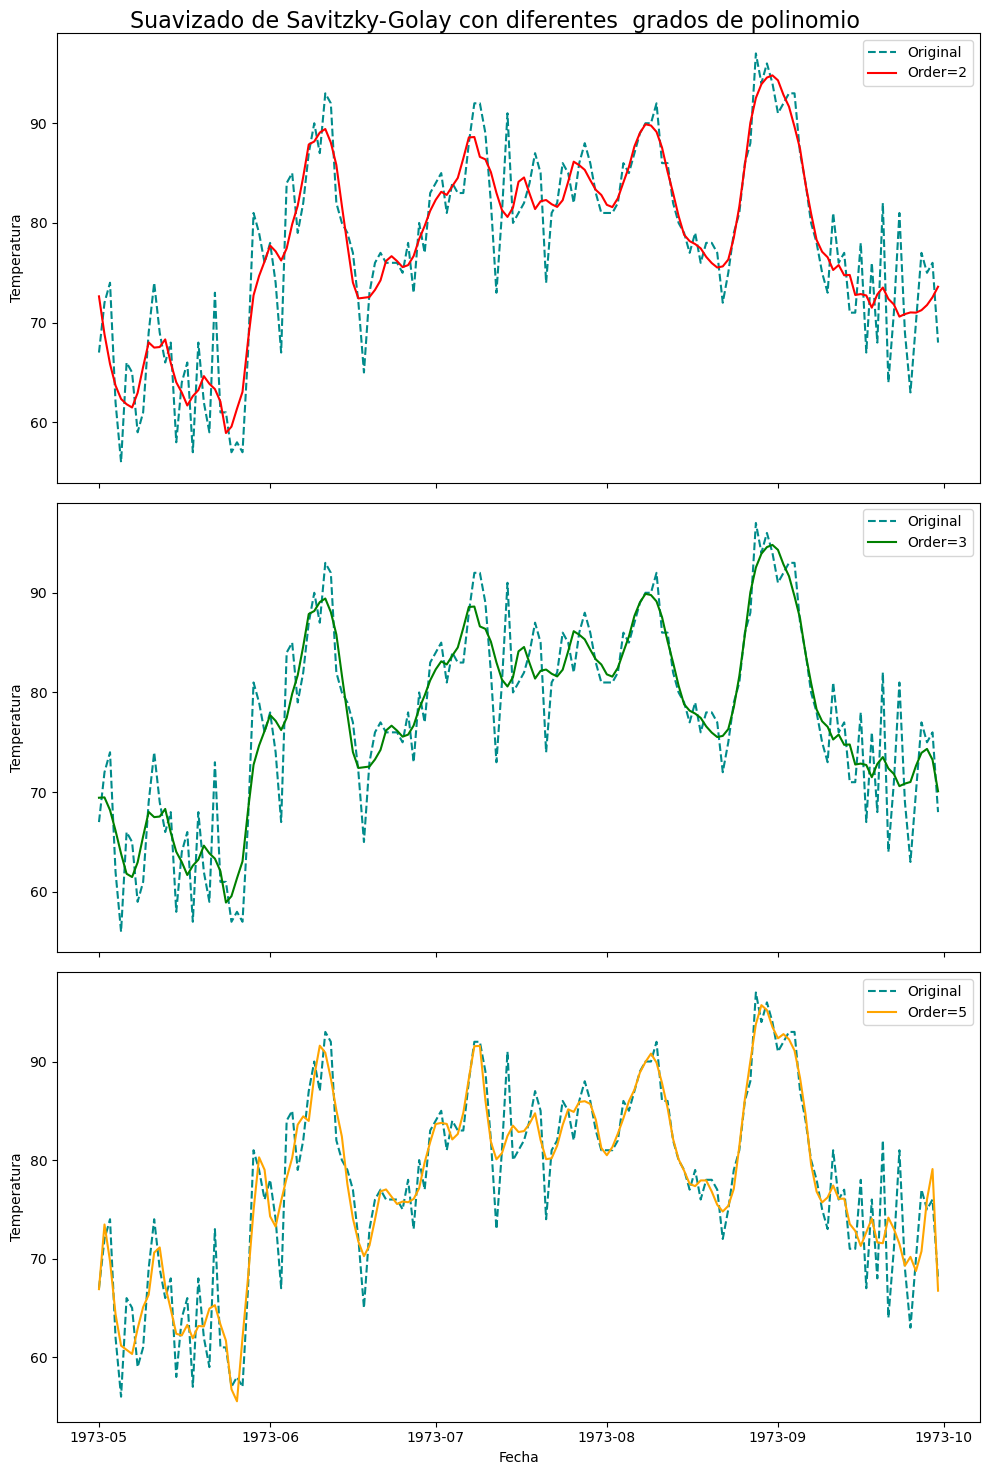

In [72]:
import matplotlib.pyplot as plt

# Crear una figura con tres subfiguras
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

# Graficar cada subfigura con la serie original y suavizada correspondiente
axes[0].plot(aire_temp['Date'], aire_temp['Temp'], label='Original', linestyle='--', color='darkcyan')
axes[0].plot(aire_temp['Date'], aire_temp['savgol_temp_11_2'], label='Order=2', color='red')
axes[0].set_ylabel('Temperatura')
axes[0].legend()

axes[1].plot(aire_temp['Date'], aire_temp['Temp'], label='Original', color='darkcyan', linestyle='--')
axes[1].plot(aire_temp['Date'], aire_temp['savgol_temp_11_3'], label='Order=3', color='green')
axes[1].set_ylabel('Temperatura')
axes[1].legend()

axes[2].plot(aire_temp['Date'], aire_temp['Temp'], label='Original', color='darkcyan', linestyle='--')
axes[2].plot(aire_temp['Date'], aire_temp['savgol_temp_11_5'], label='Order=5', color='orange')
axes[2].set_ylabel('Temperatura')
axes[2].legend()

# Configurar el título y etiquetas de los ejes
plt.xlabel('Fecha')
plt.suptitle('Suavizado de Savitzky-Golay con diferentes  grados de polinomio', fontsize=16)

# Ajustar el diseño
plt.tight_layout()
plt.show()

# Ejercicio 36

Con la serie temporal de las mediciones de los vientos (Wind) realizar ajustes polinómicos (Savitzky - Golay).

a) variando el ancho de ventana en cifras impares de 9 a 15, manteniendo fijo el grado 3.

b) variando el grado de los polinomios de 2 a 4, manteniendo fijo el ancho 13.

c) Mostrar los resultados visualmente en ambos casos.

d) Elegir el mejor ajuste (combinando los parametros adecuadamente).

e) Comparar gráficamente con el ajuste centrado de 5 medias móviles.

## <font color="#225599">Series de tiempo estacionarias</font>

Una serie de tiempo se dice que es **estrictamente estacionaria** si sus propiedades no son afectadas por los cambios a lo largo del tiempo. Es decir, que se deberían cumplir tres criterios básicos para poder considerar a una series de tiempo como estacionaria:

1) La media de la serie no debe ser una función de tiempo; sino que debe ser constante. La siguiente imagen muestra una serie que cumple con esta condición y otra que no la cumple.

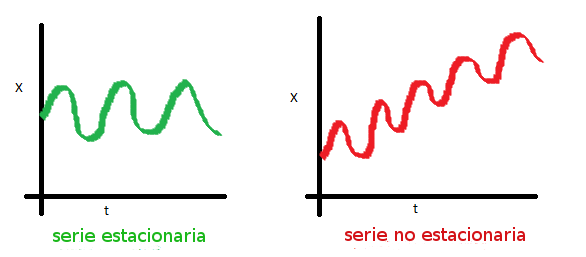

2) La varianza de la serie no debe ser una función del tiempo.

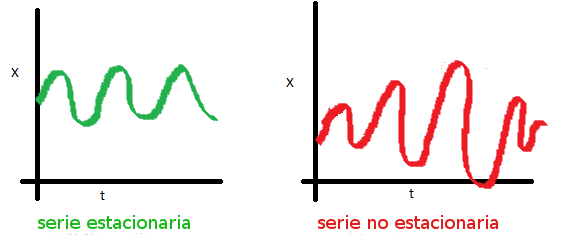

3) La covarianza de la serie no debe ser una función del tiempo.

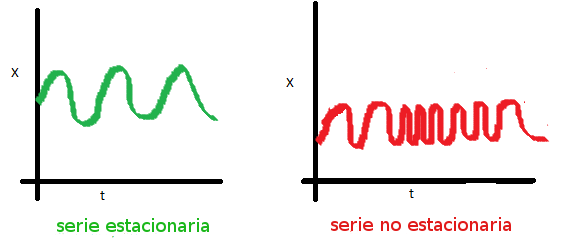

<font color="#BB3322"> A pesar de que el supuesto de que la serie es estacionaria se utiliza en muchos modelos, casi ninguna de las series de tiempo que encontramos en la práctica son estacionarias. Por tal motivo la estadística tuvo que desarrollar varias técnicas para hacer estacionaria, o lo más cercano posible a estacionaria, a una serie.</font>

In [73]:
#!pip install tslearn

In [74]:
# Importamos las bibliotecas necesarias

import tslearn
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from tslearn.preprocessing import TimeSeriesScalerMeanVariance # sirve para transformar la serie y que tenga media nula y una desviación típica igual a 1.

In [75]:
from tslearn.datasets import UCR_UEA_datasets

La base de datos del ejemplo es de nacimientos registrados por mes en la ciudad de Nueva York entre 1946 y 1959, tomados de https://a-little-book-of-r-for-time-series.readthedocs.io/en/latest/src/timeseries.html

Text(0.5, 0, 'Año')

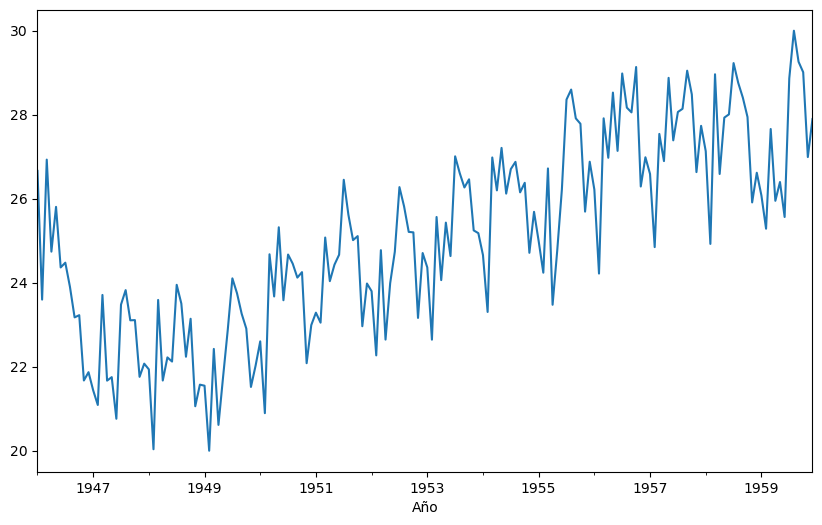

In [76]:
# Leer los datos desde la URL
url = "http://robjhyndman.com/tsdldata/data/nybirths.dat"
nacim = pd.read_csv(url, header=None, sep="\s+", names=["births"])

# Crear una serie de tiempo
nacimseries = pd.Series(nacim["births"].values, index=pd.date_range(start="1946-01", periods=len(nacim), freq="M"))

# Graficar la serie de tiempo
plt.figure(figsize=(10, 6))
nacimseries.plot()
plt.xlabel("Año")

**Ahora queremos ver cómo evolucionó a lo largo de los meses la cantidad de nacimientos por mes**

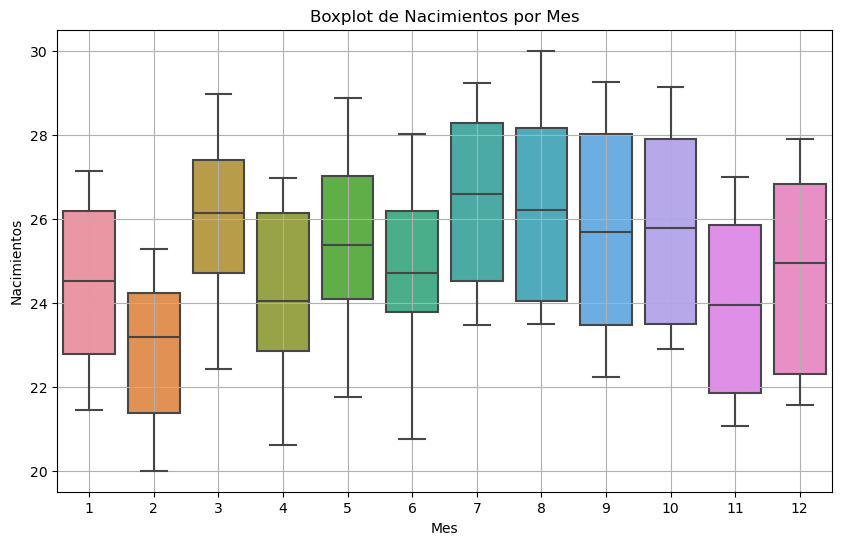

In [77]:
import seaborn as sns

# Convertir la serie de tiempo a un DataFrame
df = nacimseries.to_frame()
df.reset_index(inplace=True)
df.columns = ["Fecha", "Nacimientos"]

# Extraer el mes de la fecha
df["Mes"] = df["Fecha"].dt.month

# Crear el boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Mes", y="Nacimientos", data=df)
plt.xlabel("Mes")
plt.ylabel("Nacimientos")
plt.title("Boxplot de Nacimientos por Mes")
plt.grid(True)
plt.show()

### <font color="darkcyan">Componentes de las series de tiempo</font>


**Tendencia**: Es el patrón subyacente en los datos a lo largo del tiempo. No es necesariamente lineal.

**Estacionalidad**: Cuando una serie está influenciada por factores estacionales de periodo fijo como el dia, mes, trimestre.

**Ciclo**: Cuando los datos muestran subidas y caídas que no son del período fijo. Las fluctuaciones suelen ser de al menos 2 años.

**Aleatoriedad**: parte inexplicable de los datos


Otras definiciones incluyen el **ruido blanco (White noise)** referente a la suposición de que los valores en una serie de tiempo son aleatorios.




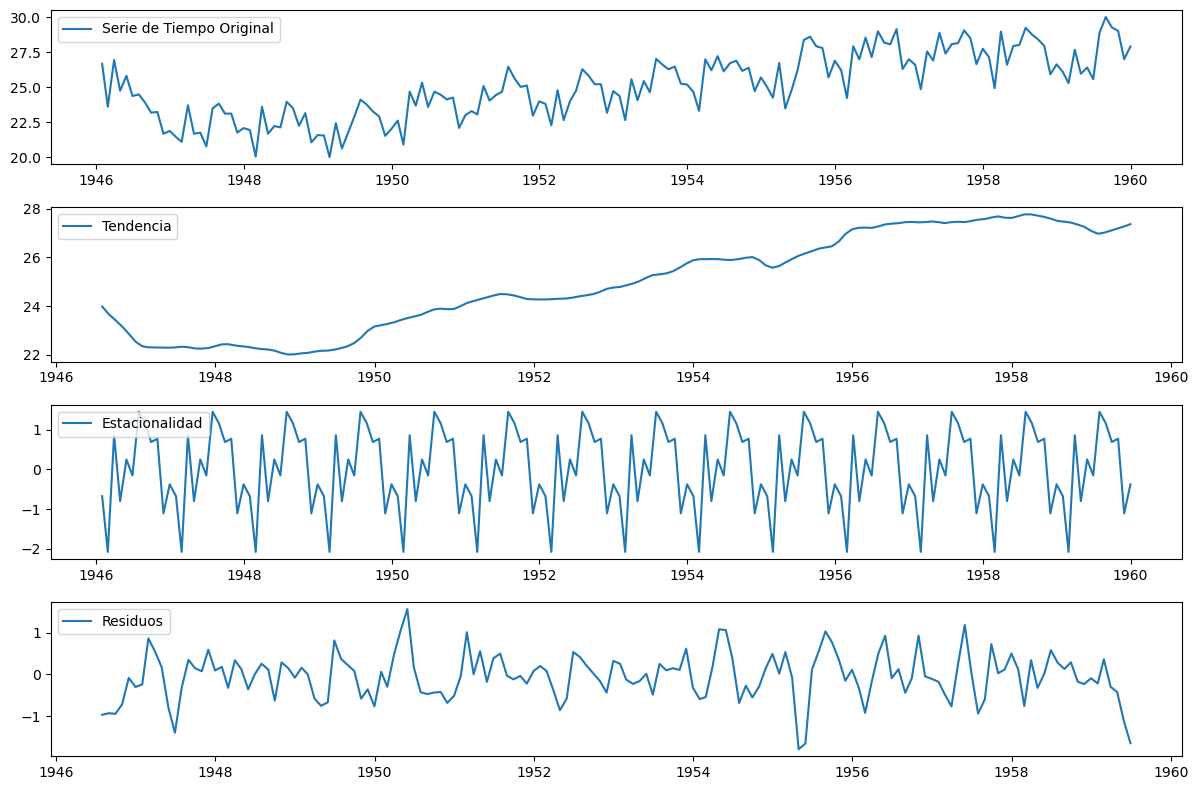

In [78]:
import statsmodels.api as sm

# Descomponer la serie de tiempo
decomposition = sm.tsa.seasonal_decompose(nacimseries, model="additive")

# Graficar la descomposición
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(nacimseries, label='Serie de Tiempo Original')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(decomposition.trend, label='Tendencia')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal, label='Estacionalidad')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(decomposition.resid, label='Residuos')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

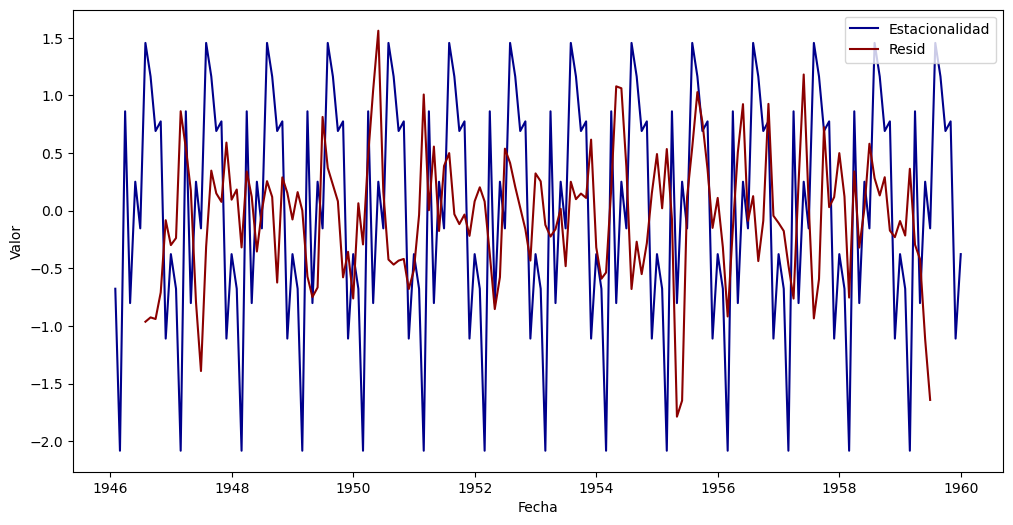

In [79]:
# Ajustamos el tamaño de la ventana
plt.figure(figsize=(12, 6))

# Graficar las componentes de la  serie de tiempo con colores diferentes
plt.plot(decomposition.seasonal, label='Estacionalidad', color='darkblue')
plt.plot(decomposition.resid, label='Resid', color='darkred')

# Agregar etiquetas y leyenda
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()

# Mostrar el gráfico
plt.show()

## Corrección de la estacionariedad (stationarity) y estacionalidad (seasonality)

Algunas técnicas para corregir la no estacionariedad (stationarity) son las siguientes:

**Ajuste por diferencial**: calcula las diferencias entre observaciones consecutivas

**Cálculo de log o raíz cuadrada**: para estabilizar la varianza no constante

**Unit root test (Prueba de raíz unitaria)**: esta prueba se usa para descubrir la primera diferencia o regresión que se debe usar para hacerla estacionaria. En la prueba Dickey-Fuller aumentada, los valores pequeños de p sugieren que se requiere una diferenciación. 






In [80]:
from statsmodels.tsa.stattools import adfuller


# Definir una función para realizar la prueba ADF y mostrar los resultados
def prueba_adf(serie):
    # Realizar la prueba ADF
    resultado_adf = adfuller(serie, autolag='AIC')

    # Extraer y mostrar los resultados
    print('Resultados de la Prueba ADF:')
    print('Estadístico de Prueba ADF:', resultado_adf[0])
    print('Valor p:', resultado_adf[1])
    print('Valores Críticos:')
    for clave, valor in resultado_adf[4].items():
        print(f'   {clave}: {valor}')

    # Interpretar los resultados
    if resultado_adf[1] <= 0.05:
        print("Conclusion: Rechazamos la hipótesis nula (H0), la serie es estacionaria.")
    else:
        print("Conclusion: No podemos rechazar la hipótesis nula (H0), la serie no es estacionaria.")

# Aplicar la prueba ADF a la serie temporal
prueba_adf(nacimseries)

Resultados de la Prueba ADF:
Estadístico de Prueba ADF: -0.3312806303805069
Valor p: 0.92095573405441
Valores Críticos:
   1%: -3.473542528196209
   5%: -2.880497674144038
   10%: -2.576878053634677
Conclusion: No podemos rechazar la hipótesis nula (H0), la serie no es estacionaria.


In [81]:
# Diferenciamos una vez la serie temporal
nacim_diferen = nacimseries.diff().dropna()

# Realizamos nuevamente la prueba ADF en la serie diferenciada para verificar la estacionariedad
prueba_adf(nacim_diferen)

Resultados de la Prueba ADF:
Estadístico de Prueba ADF: -4.495978986697172
Valor p: 0.00019995592153884546
Valores Críticos:
   1%: -3.474120870218417
   5%: -2.880749791423677
   10%: -2.5770126333102494
Conclusion: Rechazamos la hipótesis nula (H0), la serie es estacionaria.


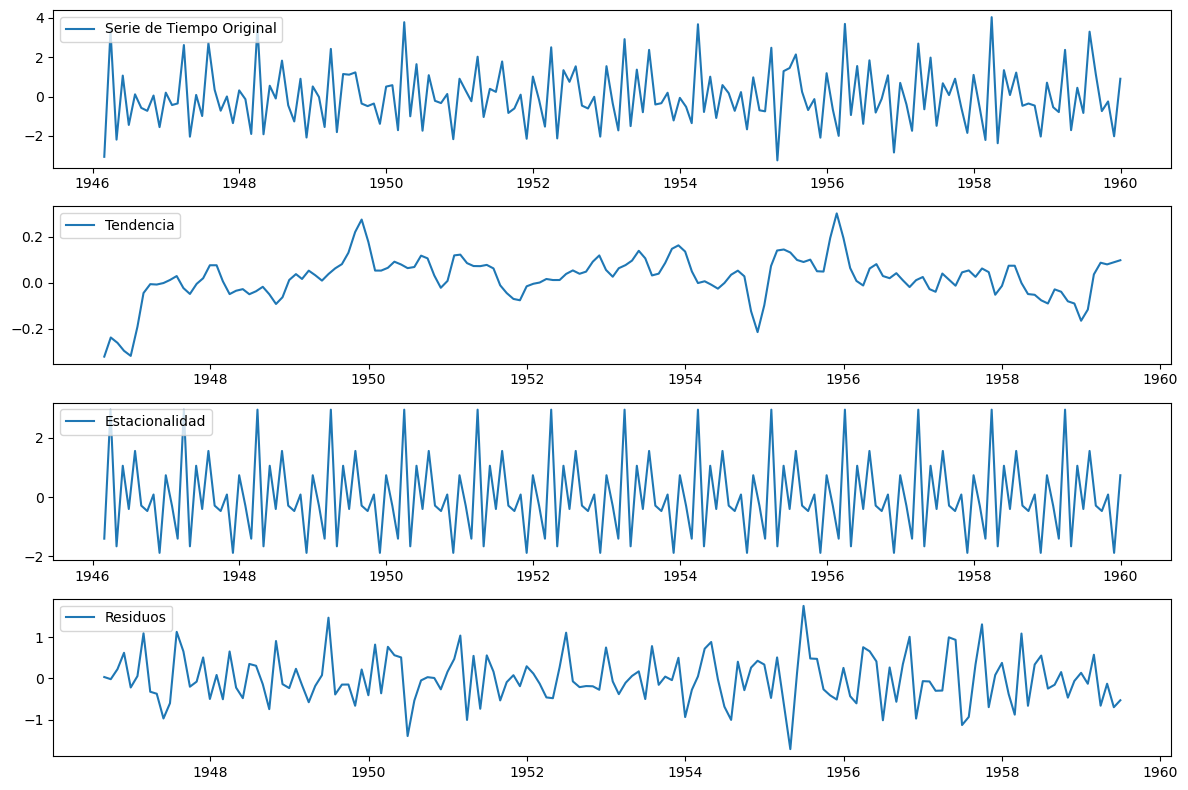

In [82]:
# Visualizamos ahora las componentes de la  serie diferenciada

import statsmodels.api as sm

# Descomponer la serie de tiempo diferenciada
decomposition1 = sm.tsa.seasonal_decompose(nacim_diferen, model="additive")

# Graficar la descomposición
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(nacim_diferen, label='Serie de Tiempo Original')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(decomposition1.trend, label='Tendencia')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(decomposition1.seasonal, label='Estacionalidad')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(decomposition1.resid, label='Residuos')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


## Forecasting

Vamos a utilizar los primeros datos para entrenar el modelo y los ultimos 6 datos para medir la bondad del ajuste

In [83]:
# Tomar los primeros valores como conjunto de entrenamiento
train = nacim_diferen[:-12]

# Tomar los últimos 6 valores como conjunto de prueba
test = nacim_diferen[-12:]


In [84]:
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing

# Suavizado exponencial simple

fit1 = SimpleExpSmoothing(train).fit(smoothing_level=0.1, optimized=False)
fcast1 = fit1.forecast(12)  # Pronóstico de 6 períodos

# Suavizado exponencial doble
fit2 = Holt(train).fit(smoothing_level=0.6, smoothing_trend=0.05, optimized=False)
fcast2 = fit2.forecast(12)  # Pronóstico de 6 períodos

# Suavizado exponencial triple
fit3 = ExponentialSmoothing(train, seasonal_periods=12, trend='add', seasonal='add').fit()
fcast3 = fit3.forecast(12)  # Pronóstico de 6 períodos

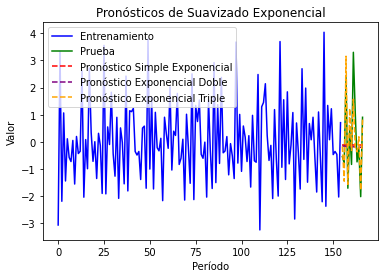

In [17]:
# Convertir train y test a arreglos de NumPy
train_values = train.values
test_values = test.values

# Graficar los valores de entrenamiento
plt.plot(np.arange(len(train_values)), train_values, label='Entrenamiento', color='blue')

# Graficar los valores de prueba
plt.plot(np.arange(len(train_values), len(train_values) + len(test_values)), test_values, label='Prueba', color='green')


# Convertir los pronósticos a arreglos de NumPy
fcast1_values = fcast1.values
fcast2_values = fcast2.values
fcast3_values = fcast3.values

# Graficar los pronósticos
plt.plot(np.arange(len(train_values), len(train_values) + len(test_values)), fcast1.values, label='Pronóstico Simple Exponencial', linestyle='--', color='red')
plt.plot(np.arange(len(train_values), len(train_values) + len(test_values)), fcast2.values, label='Pronóstico Exponencial Doble', linestyle='--', color='purple')
plt.plot(np.arange(len(train_values), len(train_values) + len(test_values)), fcast3.values, label='Pronóstico Exponencial Triple', linestyle='--', color='orange')

# Agregar etiquetas y leyenda
plt.xlabel('Período')
plt.ylabel('Valor')
plt.title('Pronósticos de Suavizado Exponencial')
plt.legend()

# Mostrar la gráfica
plt.show()

### Vamos a cuantificar ahora el error de predicción

Para  cada uno de los modelos de suavizado exponencialque hemos aplicado
Cada uno de los errores de pronóstico proporciona información sobre la precisión del modelo en relación con los valores observados. Aquí tienes una breve interpretación de cada uno de ellos:

**Error cuadrático medio (MSE)**:
        El MSE mide el promedio de los errores al cuadrado entre los valores observados y los valores pronosticados.
        Cuanto menor sea el MSE, mejor será el modelo. Un MSE más bajo indica que el modelo tiene una menor dispersión de errores y, por lo tanto, es más preciso.

**Error absoluto medio (MAE)**:
        El MAE calcula el promedio de los valores absolutos de los errores entre los valores observados y los valores pronosticados.
          El MAE es menos sensible a los valores extremos en los datos que el MSE.

**Error absoluto porcentual medio (MAPE)**:
        El MAPE calcula el promedio de los errores porcentuales absolutos entre los valores observados y los valores pronosticados.
        Es útil para evaluar la precisión relativa del modelo en términos de porcentaje de error.
        




In [85]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calcular errores para el pronóstico Simple Exponencial
mse1 = mean_squared_error(test, fcast1)
mae1 = mean_absolute_error(test, fcast1)
mape1 = np.mean(np.abs((test - fcast1) / test)) * 100

# Calcular errores para el pronóstico Exponencial Doble
mse2 = mean_squared_error(test, fcast2)
mae2 = mean_absolute_error(test, fcast2)
mape2 = np.mean(np.abs((test - fcast2) / test)) * 100

# Calcular errores para el pronóstico Exponencial 
mse3 = mean_squared_error(test, fcast3)
mae3 = mean_absolute_error(test, fcast3)
mape3 = np.mean(np.abs((test - fcast3) / test)) * 100

print("Errores del modelo de Suavizado Exponencial Simple:")
print("MSE:", mse1.round(2))
print("MAE:", mae1.round(2))
print("MAPE:", round(mape1,2))

print("Errores del modelo de Suavizado Exponencial Doble:")
print("MSE:", mse2.round(2))
print("MAE:", mae2.round(2))
print("MAPE:", round(mape2,2))

print("Errores del modelo de Suavizado Exponencial Triple:")
print("MSE:", mse3.round(2))
print("MAE:", mae3.round(2))
print("MAPE:", round(mape3,2))



Errores del modelo de Suavizado Exponencial Simple:
MSE: 2.37
MAE: 1.24
MAPE: 95.09
Errores del modelo de Suavizado Exponencial Doble:
MSE: 2.41
MAE: 1.23
MAPE: 91.31
Errores del modelo de Suavizado Exponencial Triple:
MSE: 0.6
MAE: 0.62
MAPE: 70.39


In [89]:
!pip install pmdarima 
import pmdarima as pmd

   ---------------------------------------- 0.0/614.7 kB ? eta -:--:--
   - ------------------------------------- 30.7/614.7 kB 640.0 kB/s eta 0:00:01
   --------- ------------------------------ 153.6/614.7 kB 1.8 MB/s eta 0:00:01
   --------------------------- ------------ 419.8/614.7 kB 3.3 MB/s eta 0:00:01
   ---------------------------------------- 614.7/614.7 kB 4.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.4/2.8 MB 22.4 MB/s eta 0:00:01
   ----- ---------------------------------- 0.4/2.8 MB 4.2 MB/s eta 0:00:01
   ----------------------------- ---------- 2.0/2.8 MB 16.1 MB/s eta 0:00:01
   ------------------------------------- -- 2.6/2.8 MB 15.1 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 13.7 MB/s eta 0:00:00


In [90]:
from pmdarima import auto_arima

# Ajustar el modelo Auto-ARIMA
model = auto_arima(train, seasonal=True, m=12, trace=True)

# Mostrar la descripción del modelo ajustado
print(model.summary())

# Obtener el pronóstico
fcast_autoarima = model.predict(n_periods=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=360.629, Time=1.12 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=570.255, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=425.204, Time=0.07 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=473.873, Time=0.28 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=568.255, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=inf, Time=1.48 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=417.748, Time=0.47 sec
 ARIMA(2,0,2)(2,0,1)[12] intercept   : AIC=352.907, Time=1.05 sec
 ARIMA(2,0,2)(2,0,0)[12] intercept   : AIC=381.379, Time=0.79 sec
 ARIMA(2,0,2)(2,0,2)[12] intercept   : AIC=356.266, Time=1.10 sec
 ARIMA(2,0,2)(1,0,2)[12] intercept   : AIC=349.561, Time=0.94 sec
 ARIMA(2,0,2)(0,0,2)[12] intercept   : AIC=inf, Time=1.64 sec
 ARIMA(1,0,2)(1,0,2)[12] intercept   : AIC=346.739, Time=1.10 sec
 ARIMA(1,0,2)(0,0,2)[12] intercept   : AIC=452.920, Time=0.82 sec
 ARIMA(1,0,2)(1,0,1)[12] intercept   : AI

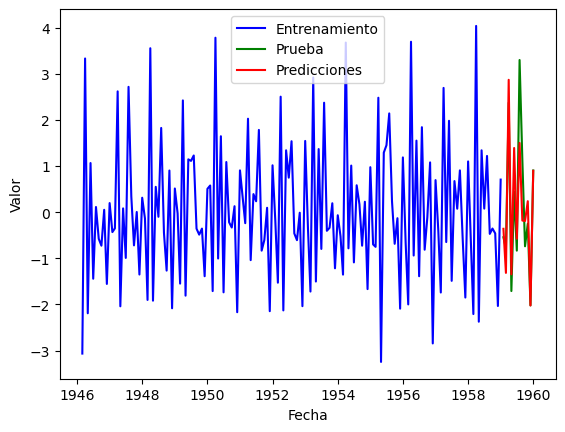

In [91]:
# Convertir train y test a arreglos de NumPy
train_values = train.values
test_values = test.values
# Convertir train.index y test.index a un array de NumPy
train_index_values = train.index.values
test_index_values = test.index.values
predictions=fcast_autoarima.values
# Visualicemos la bondad del ajuste

# Graficar los valores de entrenamiento
plt.plot(train_index_values, train_values, label='Entrenamiento', color='blue')

# Graficar los valores de prueba
plt.plot(test_index_values, test_values, label='Prueba', color='green')

# Graficar las predicciones
plt.plot(test_index_values, predictions, label='Predicciones', color='red')

# Agregar etiquetas y leyenda
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()

# Mostrar el gráfico
plt.show()

In [92]:
# Calcular errores para el pronóstico Exponencial 
mse4 = mean_squared_error(test, predictions)
mae4 = mean_absolute_error(test, predictions)
mape4 = np.mean(np.abs((test - predictions) / test)) * 100

print("Errores del modelo de ARIMA")
print("MSE:", mse4.round(2))
print("MAE:", mae4.round(2))
print("MAPE:", round(mape4,2))



Errores del modelo de ARIMA
MSE: 0.6
MAE: 0.58
MAPE: 68.88


In [93]:
import pandas as pd

# Crear un diccionario con los errores de predicción
errors = {
    'Modelo': ['Exp. Simple', 'Exp. Doble', 'Exp. Triple', 'ARIMA'],
    'MAE': [mae1.round(2), mae2.round(2), mae3.round(2), mae4.round(2)],
    'MSE': [mse1.round(2), mse2.round(2), mse3.round(2), mse4.round(2)],
    'MAPE': [round(mape1,2), round(mape2,2), round(mape3,2), round(mape4,2)]
}

# Convertir el diccionario a un DataFrame de pandas
errors_df = pd.DataFrame(errors)

# Mostrar la tabla
print(errors_df)

        Modelo   MAE   MSE   MAPE
0  Exp. Simple  1.24  2.37  95.09
1   Exp. Doble  1.23  2.41  91.31
2  Exp. Triple  0.62  0.60  70.39
3        ARIMA  0.58  0.60  68.88


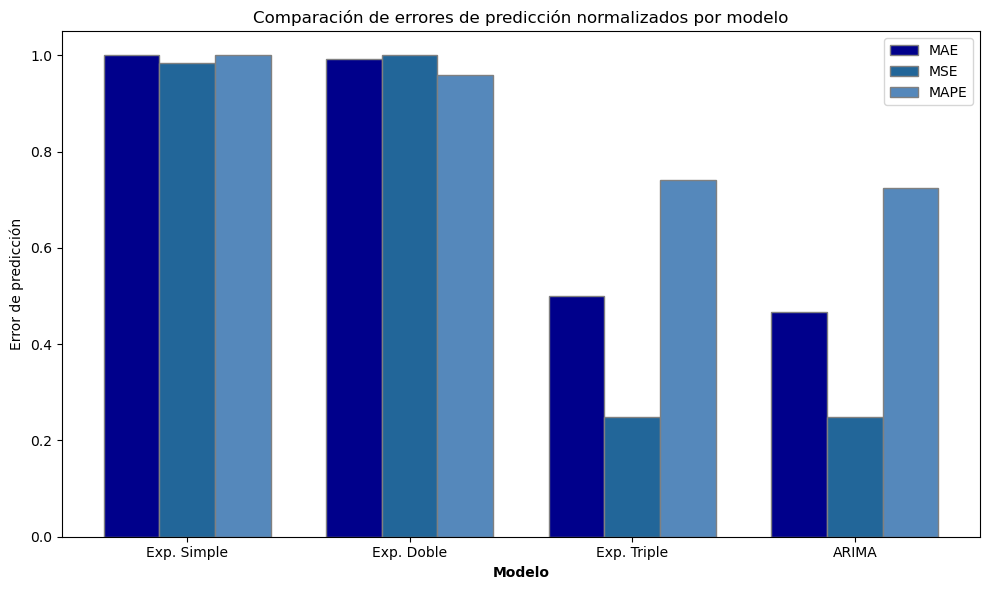

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# Normalizar los errores dividiéndolos por su valor máximo
errors_df['MAE_normalized'] = errors_df['MAE'] / errors_df['MAE'].max()
errors_df['MSE_normalized'] = errors_df['MSE'] / errors_df['MSE'].max()
errors_df['MAPE_normalized'] = errors_df['MAPE'] / errors_df['MAPE'].max()

# Configurar las posiciones de las barras
barWidth = 0.25
r1 = np.arange(len(errors_df))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

# Crear las barras
plt.figure(figsize=(10, 6))
plt.bar(r1, errors_df['MAE_normalized'], color='darkblue', width=barWidth, edgecolor='grey', label='MAE')
plt.bar(r2, errors_df['MSE_normalized'], color='#226699', width=barWidth, edgecolor='grey', label='MSE')
plt.bar(r3, errors_df['MAPE_normalized'], color='#5588BB', width=barWidth, edgecolor='grey', label='MAPE')

# Agregar etiquetas y leyenda
plt.xlabel('Modelo', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(errors_df))], errors_df['Modelo'])
plt.ylabel('Error de predicción')
plt.title('Comparación de errores de predicción normalizados por modelo')
plt.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [52]:
#!pip install typing_extensions==4.4.0
#!pip install skforecast


In [95]:
!pip install xgboost
!pip install prophet==1.1.1 --quiet
!pip install holidays==0.18.0 --quiet

   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB 330.3 kB/s eta 0:05:02
   ---------------------------------------- 0.1/99.8 MB 656.4 kB/s eta 0:02:32
   ---------------------------------------- 0.2/99.8 MB 1.8 MB/s eta 0:00:56
   ---------------------------------------- 0.7/99.8 MB 4.1 MB/s eta 0:00:25
    --------------------------------------- 1.3/99.8 MB 6.3 MB/s eta 0:00:16
    --------------------------------------- 1.3/99.8 MB 6.3 MB/s eta 0:00:16
   - -------------------------------------- 2.5/99.8 MB 8.4 MB/s eta 0:00:12
   - -------------------------------------- 3.3/99.8 MB 9.7 MB/s eta 0:00:10
   - -------------------------------------- 4.1/99.8 MB 10.2 MB/s eta 0:00:10
   - -------------------------------------- 4.7/99.8 MB 10.4 MB/s eta 0:00:10
   -- ------------------------------------- 5.3/99.8 MB 11.0 MB/s eta 0:00:09
   -- ------------------------------------- 6.1/99.8 MB 11.1 MB/s eta 0:00:0

  error: subprocess-exited-with-error
  
  exit code: 1
  
  [119 lines of output]
  <string>:13: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  running bdist_wheel
  running build
  running build_py
  creating build
  creating build\lib.win-amd64-cpython-311
  creating build\lib.win-amd64-cpython-311\prophet
  creating build\lib.win-amd64-cpython-311\prophet\stan_model
  13:50:34 - cmdstanpy - INFO - Add C++ toolchain to $PATH: C:\rtools40
  Compiling cmdstanpy model
  Add C++ toolchain to $PATH: C:\rtools40
  Installing cmdstan to C:\Users\Debora\AppData\Local\Temp\pip-install-st_4p6rd\prophet_0904e701d9aa4963811dc3de95c722b7\build\lib.win-amd64-cpython-311\prophet\stan_model\cmdstan-2.26.1
  CmdStan install directory: C:\Users\Debora\AppData\Local\Temp\pip-install-st_4p6rd\prophet_0904e701d9aa4963811dc3de95c722b7\build\lib.win-amd64-cpython-311\prophet\stan_model
  Installing CmdStan version: 2.26.1
  
  0.00B

In [97]:
# en el prompt  poner:
#pip install pystan
#pip install fbprophet

In [96]:
from prophet import Prophet
import pandas as pd

# Crear un DataFrame de pandas con las fechas y los valores de la serie temporal
df = pd.DataFrame({'ds': train.index, 'y': train.values})

# Inicializar el modelo Prophet
model_pro = Prophet()



ModuleNotFoundError: No module named 'prophet'

In [107]:
# Ajustar el modelo a los datos
model_pro.fit(df)



prophet    INFO  Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
prophet    INFO  Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
cmdstanpy  DEBUG input tempfile: C:\Users\Debora\AppData\Local\Temp\tmp0t1olmkw\elhh57w3.json
cmdstanpy  DEBUG input tempfile: C:\Users\Debora\AppData\Local\Temp\tmp0t1olmkw\rpn14t3g.json
cmdstanpy  DEBUG idx 0
cmdstanpy  DEBUG running CmdStan, num_threads: None
cmdstanpy  DEBUG CmdStan args: ['C:\\Users\\Debora\\anaconda3\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=6257', 'data', 'file=C:\\Users\\Debora\\AppData\\Local\\Temp\\tmp0t1olmkw\\elhh57w3.json', 'init=C:\\Users\\Debora\\AppData\\Local\\Temp\\tmp0t1olmkw\\rpn14t3g.json', 'output', 'file=C:\\Users\\Debora\\AppData\\Local\\Temp\\tmp0t1olmkw\\prophet_model06n9bozo\\prophet_model-20240507144810.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:48:10 - cmdstanpy - INFO - Chain [1] 

RuntimeError: Error during optimization! Command 'C:\Users\Debora\anaconda3\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=91577 data file=C:\Users\Debora\AppData\Local\Temp\tmp0t1olmkw\v0cv44m9.json init=C:\Users\Debora\AppData\Local\Temp\tmp0t1olmkw\yfrgilp4.json output file=C:\Users\Debora\AppData\Local\Temp\tmp0t1olmkw\prophet_modelsl2qo4nn\prophet_model-20240507144813.csv method=optimize algorithm=newton iter=10000' failed: 

In [ ]:
# Generar un DataFrame con las fechas futuras para las que queremos hacer la predicción
future = model_pro.make_future_dataframe(periods=12)



In [ ]:
# Realizar la predicción
forecast = model_pro.predict(future)

Vamos a trabajar con el conjunto de datos que contiene el número de pasajeros mensuales de líneas aéreas internacionales, de 1949 a 1960.


In [ ]:
# Modelado
# ==============================================================================
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

from skforecast.model_selection import backtesting_forecaster

from sklearn.metrics import mean_absolute_error